# 1. Import and Install Dependencies

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [3]:
import sys
print(sys.executable)


c:\Users\RadhaKrishna\Documents\SignAI\ISLenv\Scripts\python.exe


# 2. Keypoints using MP Holistic

In [8]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [10]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [11]:
def draw_landmarks(image, results):
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [12]:
def draw_styled_landmarks(image, results):
    # # Draw face connections
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS, 
    #                          mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
    #                          mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
    #                          ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [16]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [17]:
draw_landmarks(frame, results)

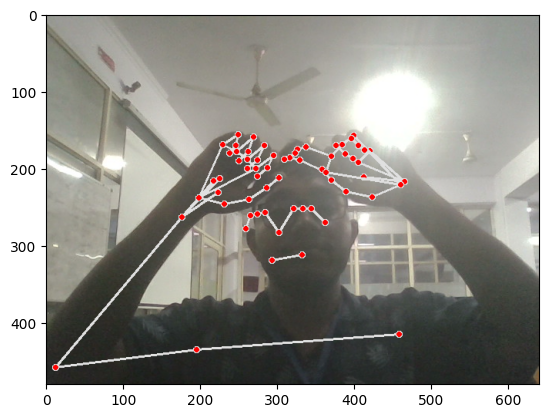

In [18]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [19]:
len(results.left_hand_landmarks.landmark)

21

In [20]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [22]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
# face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [23]:
# face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() 
# if results.face_landmarks
# else np.zeros(1404)


In [24]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [25]:
result_test = extract_keypoints(results)

In [26]:
result_test

array([ 0.47237372,  0.59137279, -0.97144747, ...,  0.37208337,
        0.37580404, -0.00482404])

In [27]:
np.save('0', result_test)

In [28]:
np.load('0.npy')

array([ 0.47237372,  0.59137279, -0.97144747, ...,  0.37208337,
        0.37580404, -0.00482404])

# 4. Setup Folders for Collection

In [38]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['0','1','2','3','4','5','6','7','8','9',
                     'A','B','C','D','E','F','G','H','I','J','K','L','M',
                     'N','O','P','Q','R','S','T','U','V','W','X','Y','Z'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 30

no_samples = 200  # static snapshots to collect per class, not 30-frame videos

for action in actions:
    os.makedirs(os.path.join(DATA_PATH, action), exist_ok=True)

In [40]:
# for action in actions: 
#     dirmax = np.max(np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int))
#     for sequence in range(1,no_sequences+1):
#         try: 
#             os.makedirs(os.path.join(DATA_PATH, action, str(dirmax+sequence)))
#         except:
#             pass

# 5. Collect Keypoint Values for Training and Testing

In [41]:
import cv2
import numpy as np
import os
import mediapipe as mp

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

DATA_PATH = 'MP_Data'
no_samples = 200  # target samples per class

# ---- helper: run a frame through mediapipe ----
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

# ---- helper: extract flat 126-length keypoint vector (both hands, no face/pose) ----
def extract_hand_keypoints(results):
    left = np.zeros(21*3)
    right = np.zeros(21*3)
    if results.multi_hand_landmarks:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            coords = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]).flatten()
            if handedness.classification[0].label == 'Left':
                left = coords
            else:
                right = coords
    return np.concatenate([left, right])

# ---- helper: draw landmarks, color-coded left/right ----
def draw_styled_landmarks(image, results):
    if results.multi_hand_landmarks:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            if handedness.classification[0].label == 'Left':
                landmark_spec = mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4)
                connection_spec = mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
            else:
                landmark_spec = mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4)
                connection_spec = mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
            mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                                       landmark_spec, connection_spec)

# ---- main collection loop ----
cap = cv2.VideoCapture(0)
with mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5) as hands:
    for action in actions:
        os.makedirs(os.path.join(DATA_PATH, action), exist_ok=True)
        existing = os.listdir(os.path.join(DATA_PATH, action))
        start_index = max([int(f.split('.')[0]) for f in existing], default=-1) + 1

        collecting = False
        collected = 0
        quit_all = False

        while collected < no_samples:
            ret, frame = cap.read()
            frame = cv2.flip(frame, 1)  # mirror view
            image, results = mediapipe_detection(frame, hands)
            draw_styled_landmarks(image, results)

            status = "COLLECTING" if collecting else "Press 's' to start"
            cv2.putText(image, f'{action}: {collected}/{no_samples}  [{status}]', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.imshow('ISL Data Collection', image)


            key = cv2.waitKey(10) & 0xFF
            if key == ord('s'):
                collecting = True
            elif key == ord('q'):
                quit_all = True
                break

            if collecting and results.multi_hand_landmarks:
                keypoints = extract_hand_keypoints(results)
                np.save(os.path.join(DATA_PATH, action, f'{start_index + collected}.npy'), keypoints)
                collected += 1

        if quit_all:
            break

cap.release()

cv2.destroyAllWindows()

In [158]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [42]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [43]:
label_map = {label:num for num, label in enumerate(actions)}

In [44]:
label_map

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9,
 'A': 10,
 'B': 11,
 'C': 12,
 'D': 13,
 'E': 14,
 'F': 15,
 'G': 16,
 'H': 17,
 'I': 18,
 'J': 19,
 'K': 20,
 'L': 21,
 'M': 22,
 'N': 23,
 'O': 24,
 'P': 25,
 'Q': 26,
 'R': 27,
 'S': 28,
 'T': 29,
 'U': 30,
 'V': 31,
 'W': 32,
 'X': 33,
 'Y': 34,
 'Z': 35}

In [46]:
from tensorflow.keras.utils import to_categorical

label_map = {label: num for num, label in enumerate(actions)}

sequences, labels = [], []
for action in actions:
    action_folder = os.path.join(DATA_PATH, action)
    for file_name in os.listdir(action_folder):
        if file_name.endswith('.npy'):
            keypoints = np.load(os.path.join(action_folder, file_name))
            sequences.append(keypoints)
            labels.append(label_map[action])

X = np.array(sequences)   # shape: (num_samples, 126)
y = to_categorical(labels).astype(int)   # shape: (num_samples, 36)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=labels)

In [47]:
np.array(sequences).shape

(7200, 126)

In [48]:
np.array(labels).shape

(7200,)

In [49]:
X = np.array(sequences)

In [50]:
X.shape

(7200, 126)

In [51]:
y = to_categorical(labels).astype(int)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [53]:
y_test.shape

(360, 36)

In [60]:
X

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         9.08920050e-01,  2.13161379e-01, -1.22436918e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         9.08760428e-01,  2.12803006e-01, -1.22831188e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         8.92449141e-01,  2.11989701e-01, -1.23561040e-01],
       ...,
       [ 3.73622447e-01,  8.24612916e-01,  4.15957686e-07, ...,
         4.96594012e-01,  5.40761352e-01, -8.63292515e-02],
       [ 3.77871037e-01,  8.23526084e-01,  3.72724173e-07, ...,
         5.02001524e-01,  5.44487655e-01, -8.48576948e-02],
       [ 3.76016021e-01,  8.27196002e-01,  4.04830843e-07, ...,
         4.98137146e-01,  5.41310668e-01, -8.59769061e-02]])

In [62]:
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

# 7. Build and Train MLP Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import TensorBoard

In [55]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard
import os

log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

model = Sequential([
    Dense(128, activation='relu', input_shape=(126,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(actions.shape[0], activation='softmax')
])
model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.fit(X_train, y_train, epochs=200, callbacks=[tb_callback])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               16256     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 36)                2340      
                                                                 
Total params: 26852 (104.89 KB)
Trainable params: 26852 (104.89 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/200


214/214 [==============================] - 2s 4ms/step - loss: 2.7566 - categorical_accuracy: 0.2183
Epoch 2/200
214/214 [============

# 8. Make Predictions

In [64]:
res = model.predict(X_test)

12/12 [==============================] - 0s 1ms/step


In [65]:
actions[np.argmax(res[4])]

'2'

In [66]:
actions[np.argmax(y_test[4])]

'2'

# 9. Save Weights

In [67]:
model.save('outputs/action.h5')

c:\Users\RadhaKrishna\Documents\SignAI\ISLenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [217]:
del model

In [4]:
from tensorflow.keras.models import load_model
model = load_model('outputs/action.h5')

In [5]:
# model.load_weights('outputs/action.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [68]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [69]:
yhat = model.predict(X_test)

12/12 [==============================] - 0s 1ms/step


In [70]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [71]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[347,   0],
        [  0,  13]],

       [[342,   0],
        [  0,  18]],

       [[347,   0],
        [  0,  13]],

       [[352,   0],
        [  0,   8]],

       [[348,   0],
        [  1,  11]],

       [[345,   1],
        [  0,  14]],

       [[349,   0],
        [  0,  11]],

       [[351,   0],
        [  0,   9]],

       [[343,   0],
        [  0,  17]],

       [[352,   0],
        [  0,   8]],

       [[354,   0],
        [  0,   6]],

       [[350,   0],
        [  0,  10]],

       [[349,   0],
        [  0,  11]],

       [[354,   0],
        [  0,   6]],

       [[352,   0],
        [  0,   8]],

       [[350,   0],
        [  0,  10]],

       [[354,   0],
        [  0,   6]],

       [[346,   0],
        [  0,  14]],

       [[354,   0],
        [  0,   6]],

       [[352,   0],
        [  0,   8]],

       [[349,   0],
        [  0,  11]],

       [[353,   0],
        [  0,   7]],

       [[349,   0],
        [  0,  11]],

       [[353,   0],
        [  1, 

In [72]:
accuracy_score(ytrue, yhat)

0.9944444444444445

# 11. Test in Real Time

In [73]:
from scipy import stats

In [16]:
actions = np.array(['0','1','2','3','4','5','6','7','8','9',
                     'A','B','C','D','E','F','G','H','I','J','K','L','M',
                     'N','O','P','Q','R','S','T','U','V','W','X','Y','Z'])

In [15]:
import matplotlib.pyplot as plt

# one distinct color per class, generated automatically instead of hardcoded
colors = [tuple(int(c*255) for c in plt.cm.hsv(i/len(actions))[:3]) for i in range(len(actions))]

def prob_viz(res, actions, input_frame, colors, top_n=5):
    output_frame = input_frame.copy()
    top_indices = np.argsort(res)[-top_n:][::-1]  # show only the top-N most likely classes
    for i, num in enumerate(top_indices):
        prob = res[num]
        cv2.rectangle(output_frame, (0, 60+i*40), (int(prob*100), 90+i*40), colors[num], -1)
        cv2.putText(output_frame, f'{actions[num]}: {prob:.2f}', (0, 85+i*40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
    return output_frame

In [21]:
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
with mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5) as hands:
    while cap.isOpened():
        ret, frame = cap.read()
        frame = cv2.flip(frame, 1)

        image, results = mediapipe_detection(frame, hands)
        draw_styled_landmarks(image, results)

        keypoints = extract_hand_keypoints(results)
        res = model.predict(np.expand_dims(keypoints, axis=0), verbose=0)[0]
        predictions.append(np.argmax(res))

        # stability check: only accept a prediction once it's been consistent recently
        if np.unique(predictions[-10:])[0] == np.argmax(res):
            if res[np.argmax(res)] > threshold:
                if len(sentence) > 0:
                    if actions[np.argmax(res)] != sentence[-1]:
                        sentence.append(actions[np.argmax(res)])
                else:
                    sentence.append(actions[np.argmax(res)])

        if len(sentence) > 5:
            sentence = sentence[-5:]

        image = prob_viz(res, actions, image, colors)

        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)

        cv2.imshow('ISL Real-Time Test', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()